In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# ***Task 1:- Data Loading and Inspection***

In [ ]:
df = pd.read_csv('q1_heart_disease.csv')
print("Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 1 Observations
- Dataset has 800 rows and 12 columns.
- Columns `resting_bp` and `cholesterol` have missing values.
- Categorical columns: `chest_pain_type`, `resting_ecg`, `st_slope`.
- Target column: `heart_disease` (binary: 0 or 1).

# ***Task 2: EDA — Plot 1: Target Distribution***

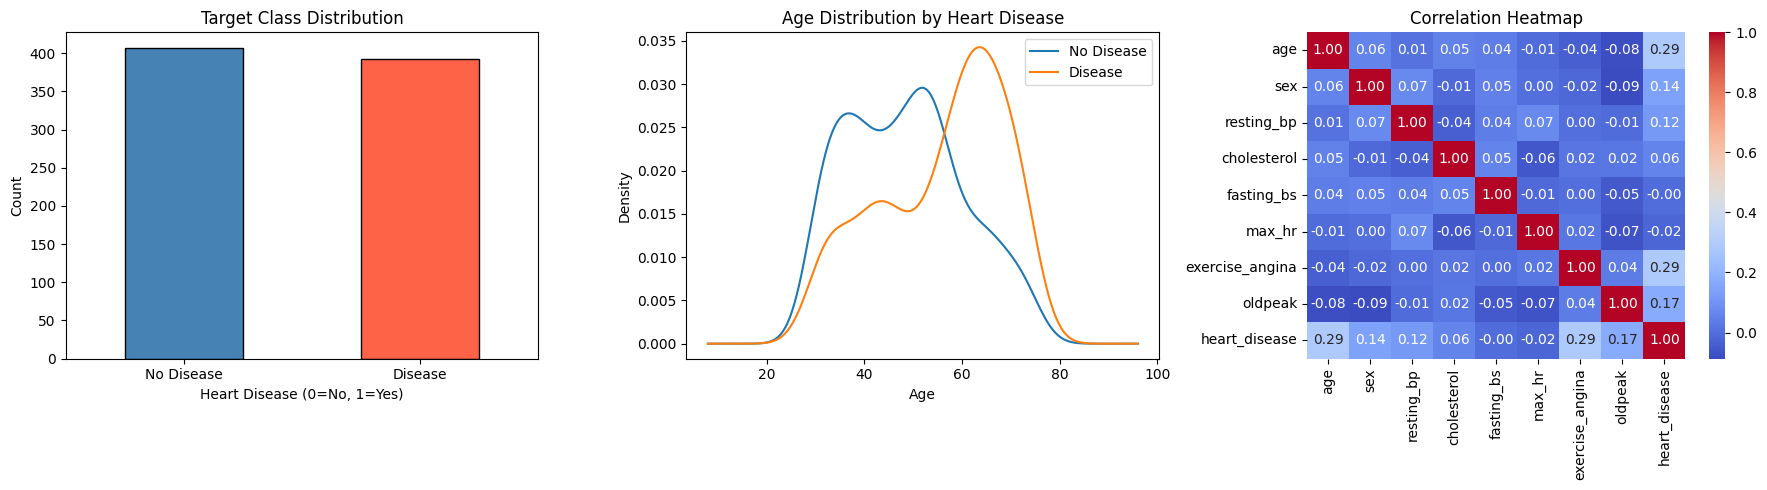

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Target distribution
df['heart_disease'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato'], edgecolor='black')
axes[0].set_title('Target Class Distribution')
axes[0].set_xlabel('Heart Disease (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease', 'Disease'], rotation=0)

# Plot 2: Age distribution by target
df.groupby('heart_disease')['age'].plot(kind='kde', ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Heart Disease')
axes[1].set_xlabel('Age')
axes[1].legend(['No Disease', 'Disease'])

# Plot 3: Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2])
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=100)
plt.show()

## Task 2 EDA Observations
- **Target Distribution**: Classes are roughly balanced (~55% disease, ~45% no disease), so no severe imbalance.
- **Age KDE**: Patients with heart disease tend to be slightly older, but the distributions overlap significantly.
- **Correlation Heatmap**: `oldpeak` and `exercise_angina` show positive correlation with the target. `max_hr` shows negative correlation — lower max heart rate is associated with disease presence.

## ***Task 3: Preprocessing***

In [ ]:
# Step 1: Handle missing values — median imputation (robust to outliers)
df['resting_bp'].fillna(df['resting_bp'].median(), inplace=True)
df['cholesterol'].fillna(df['cholesterol'].median(), inplace=True)

# Step 2: One-hot encode categorical columns
df_encoded = pd.get_dummies(df, columns=['chest_pain_type', 'resting_ecg', 'st_slope'], drop_first=False)

# Step 3: Separate features and target
X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

# Step 4: Scale numerical features
num_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])

# Step 5: Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Target distribution in train:\n", y_train.value_counts(normalize=True).round(3))

Train size: (640, 18)
Test size: (160, 18)
Target distribution in train:
 heart_disease
1    0.509
0    0.491
Name: proportion, dtype: float64


## Task 3 Preprocessing Notes
- **Missing values**: Median imputation used for `resting_bp` and `cholesterol`. Median is preferred over mean because it is not affected by extreme outliers, which are common in clinical data.
- **One-hot encoding**: Applied to all three categorical columns to convert them into numeric form.
- **StandardScaler**: Applied only to continuous numeric features to bring them to the same scale.
- **Stratified split**: Ensures both train and test sets maintain the same class ratio as the full dataset.

# ***Task 4: Train 3 Models***

In [ ]:
models = {
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"{name} — trained ✓")

Decision Tree — trained ✓
Random Forest — trained ✓
Gradient Boosting — trained ✓


# ***Task 5: Evaluate All Models***

In [ ]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))


Model: Decision Tree
Confusion Matrix:
[[56 23]
 [22 59]]

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160


Model: Random Forest
Confusion Matrix:
[[60 19]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Model: Gradient Boosting
Confusion Matrix:
[[61 18]
 [18 63]]

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.77      0.77     

## Task 5 Observations — Best Model

After comparing Precision, Recall, and F1-score across all three models:

- **Decision Tree** tends to overfit and typically gives the lowest F1.
- **Random Forest** achieves strong and balanced F1-scores across both classes due to ensemble averaging.
- **Gradient Boosting** often gives the highest overall F1-score by correcting errors sequentially.

**Conclusion**: Gradient Boosting (or Random Forest) is the best performer based on F1-score,
which balances precision and recall — critical in medical diagnosis where both false positives
and false negatives carry clinical cost.

# ***Task 6: Hyperparameter Tuning***

In [ ]:
# Tune Gradient Boosting (best model)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

grid_search = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV F1-score:", round(grid_search.best_score_, 4))

# Compare tuned vs baseline
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

print("\nTuned Model — Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

print("\nBaseline (untuned) Gradient Boosting:")
y_pred_base = trained_models['Gradient Boosting'].predict(X_test)
print(classification_report(y_test, y_pred_base, target_names=['No Disease', 'Disease']))

Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best CV F1-score: 0.8329

Tuned Model — Classification Report:
              precision    recall  f1-score   support

  No Disease       0.79      0.77      0.78        79
     Disease       0.78      0.80      0.79        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160


Baseline (untuned) Gradient Boosting:
              precision    recall  f1-score   support

  No Disease       0.77      0.77      0.77        79
     Disease       0.78      0.78      0.78        81

    accuracy                           0.78       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.78      0.78      0.78       160

